#**Projeto Aprendizagem de Máquina - 2025.2**

Grupo:
* Jéssica Maria
* Vinícius José



---



Este projeto abordará um problema de **Regressão**.

**Escolha da Base de Dados:**

utiliza dados históricos de vazões diárias (em m³/s) de três importantes usinas hidrelétricas brasileiras: Ilha Solteira, Jupiá e Passo Real. Os dados cobrem um longo período, de 1931 a 2016, permitindo uma análise temporal robusta. O estudo de vazões é fundamental para o planejamento energético nacional, gestão de recursos hídricos e previsão de eventos extremos (secas ou cheias).

**Objetivo:** prever um valor numérico contínuo: a vazão diária (em m³/s) de uma usina hidrelétrica.


---






## PARTE 1 — Importações + Carregamento da Base + EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns             # gráficos mais bonitos na análise exploratória

from datetime import datetime      # converter strings de datas para objetos datetime

from sklearn.preprocessing import MinMaxScaler   # normalização de X e y sem vazamento

from sklearn.neighbors import KNeighborsRegressor   # modelo KNN (baseline)
from sklearn.model_selection import TimeSeriesSplit   # validação cruzada temporal
from sklearn.metrics import mean_absolute_error, mean_squared_error   # métricas MAE e MSE

from scipy.stats import wilcoxon   # teste de hipótese: compara erros dos modelos

import tensorflow as tf            # backend do Keras (treino da MLP)
from tensorflow.keras.models import Sequential   # modelo sequencial para a MLP
from tensorflow.keras.layers import Dense        # camadas densas da MLP
from tensorflow.keras.optimizers import Adam     # otimizador usado no random search
from tensorflow.keras.callbacks import EarlyStopping   # parar treino automático se não melhorar

import random    # amostragem aleatória de hiperparâmetros (Random Search)


In [ ]:
# Configurações visuais
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

# ----------- Carregamento da Base -----------

# URL DE DOWNLOAD DIRETO DO GOOGLE DRIVE
url = "https://drive.google.com/uc?export=download&id=1JMALdp_zahSRRPaIkNGHYohlTmntmXLj"
"""

uncomment abaixo para carregar outros bds
"""
#url =

# Leitura do CSV
df = pd.read_csv(url, sep=",", header=0, names=["Data", "Vazao"])

print("Primeiras linhas do dataset:")
display(df.head())

print("\nFormato do dataset:", df.shape)


print("\n end ")

Primeiras linhas do dataset:


,Data,Vazao
0,1/jan/1931,16060
1,2/jan/1931,15935
2,3/jan/1931,15559
3,4/jan/1931,15309
4,5/jan/1931,15109



Formato do dataset: (31412, 2)

 end 


* Transforma a coluna “Data” em datetime, remove valores inválidos, ordena a série e exibe estatísticas descritivas.

In [ ]:
# ----------- Conversão de Datas -----------
# Converte a coluna Data para formato datetime
df["Data"] = pd.to_datetime(df["Data"], dayfirst=True, errors="coerce")

# Remover possíveis linhas inválidas
df = df.dropna().reset_index(drop=True)

# Garantir ordenação temporal
df = df.sort_values("Data").reset_index(drop=True)

print("\nApós conversão e limpeza:")
display(df.head())

# ----------- Estatísticas Básicas -----------

print("\nEstatísticas descritivas:")
display(df["Vazao"].describe())

# ----------- Verificando valores nulos -----------
print("\nNulos por coluna:")
print(df.isna().sum())

print("\n end ")

/tmp/ipython-input-1346718202.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Data"] = pd.to_datetime(df["Data"], dayfirst=True, errors="coerce")



Após conversão e limpeza:


,Data,Vazao
0,1931-01-01,16060
1,1931-01-02,15935
2,1931-01-03,15559
3,1931-01-04,15309
4,1931-01-05,15109



Estatísticas descritivas:


,Vazao
count,13158.000000
mean,6949.977732
std,4063.446305
min,1978.000000
25%,4009.250000
50%,5203.500000
75%,9398.000000
max,25387.000000



Nulos por coluna:
Data     0
Vazao    0
dtype: int64

 end 


* Plotagem dos gráficos

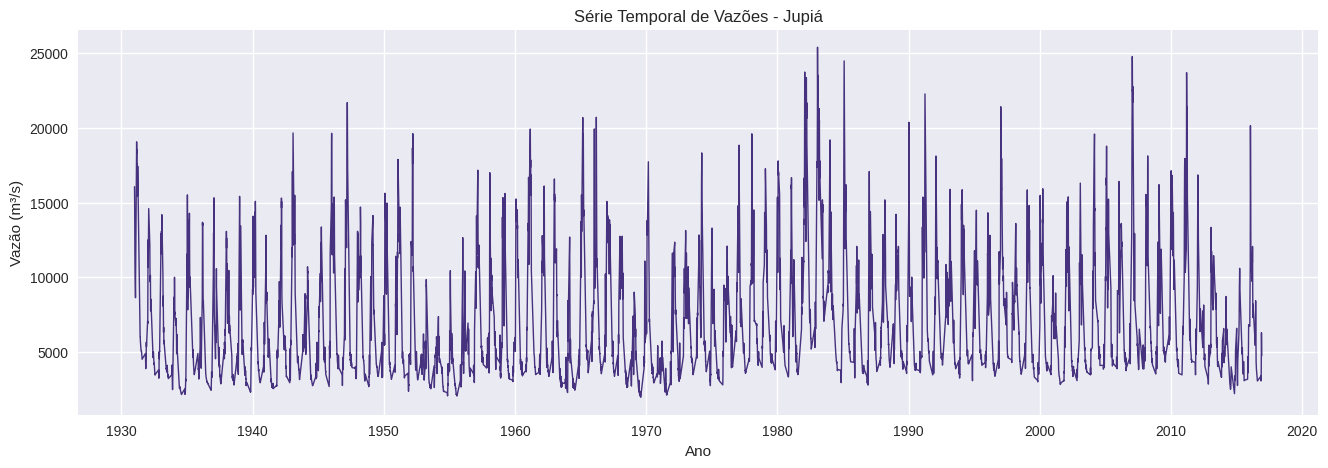

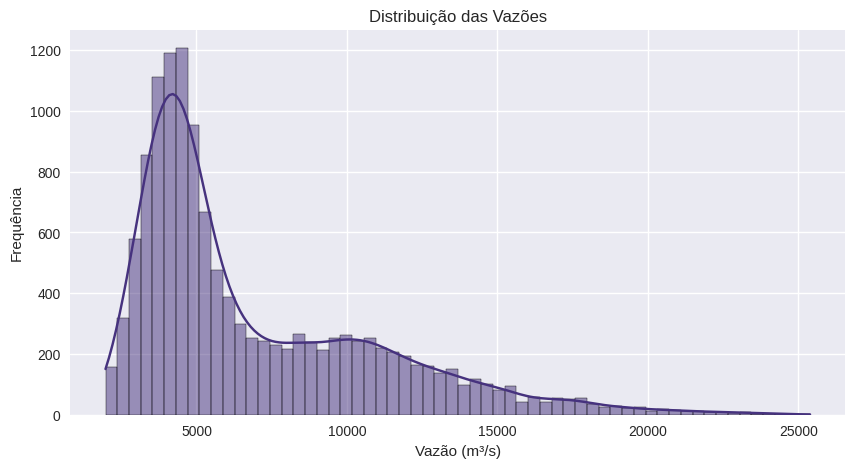

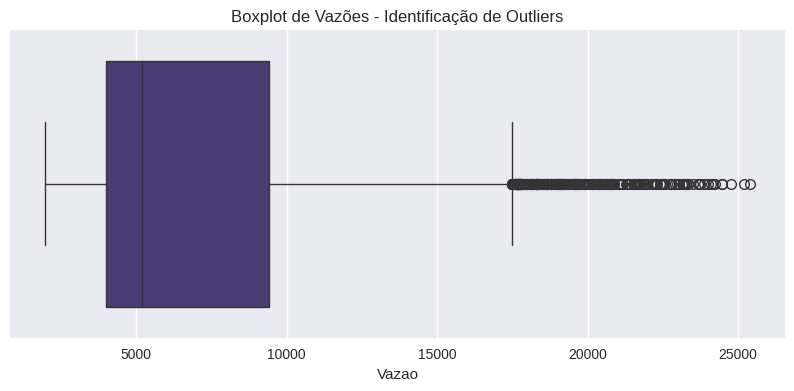


 end


In [ ]:
# ----------- Plot da Série Temporal -----------

plt.figure(figsize=(16,5))
plt.plot(df["Data"], df["Vazao"], linewidth=1)
plt.title("Série Temporal de Vazões - Jupiá")
plt.xlabel("Ano")
plt.ylabel("Vazão (m³/s)")
plt.grid(True)
plt.show()

# ----------- Distribuição da Vazão -----------

plt.figure(figsize=(10,5))
sns.histplot(df["Vazao"], bins=60, kde=True)
plt.title("Distribuição das Vazões")
plt.xlabel("Vazão (m³/s)")
plt.ylabel("Frequência")
plt.show()

# ----------- Boxplot para Outliers -----------

plt.figure(figsize=(10,4))
sns.boxplot(x=df["Vazao"])
plt.title("Boxplot de Vazões - Identificação de Outliers")
plt.show()

print("\n end")

## PARTE 2 — Pré-Processamento Completo

In [ ]:
# ---------- 2.1 Função de criação de janelas (lags) ----------

def create_window(series, window_size=30, horizon=7):
    """
    Transforma série em pares (X, y) com:
    - X: 'window_size' valores passados
    - y: 'horizon' valores futuros
    """
    X, y = [], []

    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size : i + window_size + horizon])

    return np.array(X), np.array(y)


# ---------- 2.2 Criar datasets para janelas 15 / 30 / 45 ----------

vazoes = df["Vazao"].values.astype(float)
datas  = df["Data"].values

datasets = {}
date_maps = {}

WINDOWS = [15, 30, 45]
HORIZON = 7

for w in WINDOWS:
    X, y = create_window(vazoes, window_size=w, horizon=HORIZON)

    # datas alinhadas à saída y
    aligned_dates = datas[w + HORIZON - 1 :]

    # garantir alinhamento perfeito
    aligned_dates = aligned_dates[:len(y)]

    datasets[w] = (X, y)
    date_maps[w] = aligned_dates

    print(f"Janela {w} dias → X: {X.shape}, y: {y.shape}, datas: {aligned_dates.shape}")


# ---------- 2.3 Separação temporal usando datas alinhadas ----------
split_date = np.datetime64("2011-01-01")

X_train_dict, y_train_dict = {}, {}
X_val_dict,   y_val_dict   = {}, {}
X_test_dict,  y_test_dict  = {}, {}
scalers = {}


for w in WINDOWS:

    X, y = datasets[w]
    dates_w = date_maps[w]

    # Máscaras temporais específicas para esta janela
    train_mask = dates_w < split_date
    test_mask  = dates_w >= split_date

    X_train_all, X_test = X[train_mask], X[test_mask]
    y_train_all, y_test = y[train_mask], y[test_mask]

    # Divisão 80/20 dentro do treino (HOLD-OUT)
    split_idx = int(0.8 * len(X_train_all))

    X_tr, X_val = X_train_all[:split_idx], X_train_all[split_idx:]
    y_tr, y_val = y_train_all[:split_idx], y_train_all[split_idx:]

    # -------- Normalização SEM VAZAMENTO --------
    scaler_X = MinMaxScaler().fit(X_tr)
    scaler_y = MinMaxScaler().fit(y_tr)

    scalers[w] = (scaler_X, scaler_y)

    # Transformar dados
    X_tr_s  = scaler_X.transform(X_tr)
    X_val_s = scaler_X.transform(X_val)
    X_test_s = scaler_X.transform(X_test)

    y_tr_s  = scaler_y.transform(y_tr)
    y_val_s = scaler_y.transform(y_val)
    y_test_s = scaler_y.transform(y_test)

    # Salvar
    X_train_dict[w], y_train_dict[w] = X_tr_s, y_tr_s
    X_val_dict[w],   y_val_dict[w]   = X_val_s, y_val_s
    X_test_dict[w],  y_test_dict[w]  = X_test_s, y_test_s

    print(f"\n--- Janela {w} ---")
    print(f"Treino: {X_tr_s.shape} | Val: {X_val_s.shape} | Teste: {X_test_s.shape}")

print("\n end 2")


Janela 15 dias → X: (13137, 15), y: (13137, 7), datas: (13137,)
Janela 30 dias → X: (13122, 30), y: (13122, 7), datas: (13122,)
Janela 45 dias → X: (13107, 45), y: (13107, 7), datas: (13107,)

--- Janela 15 ---
Treino: (9775, 15) | Val: (2444, 15) | Teste: (918, 15)

--- Janela 30 ---
Treino: (9763, 30) | Val: (2441, 30) | Teste: (918, 30)

--- Janela 45 ---
Treino: (9751, 45) | Val: (2438, 45) | Teste: (918, 45)

 end 2


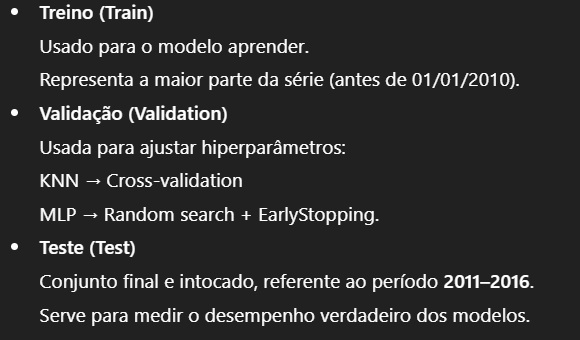

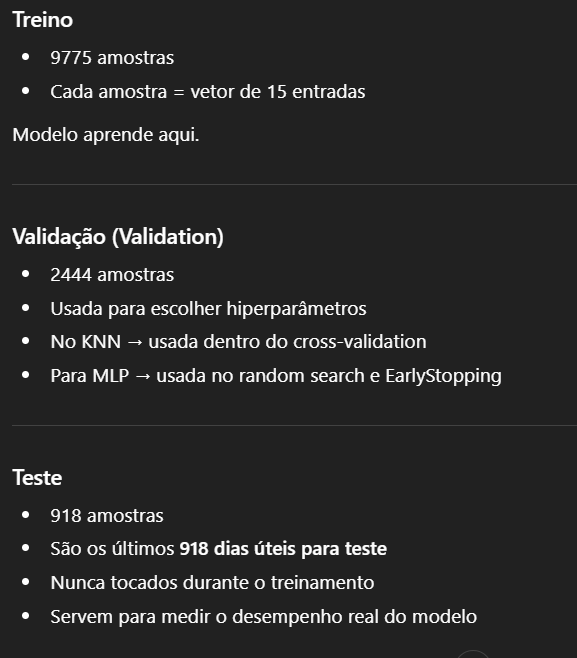

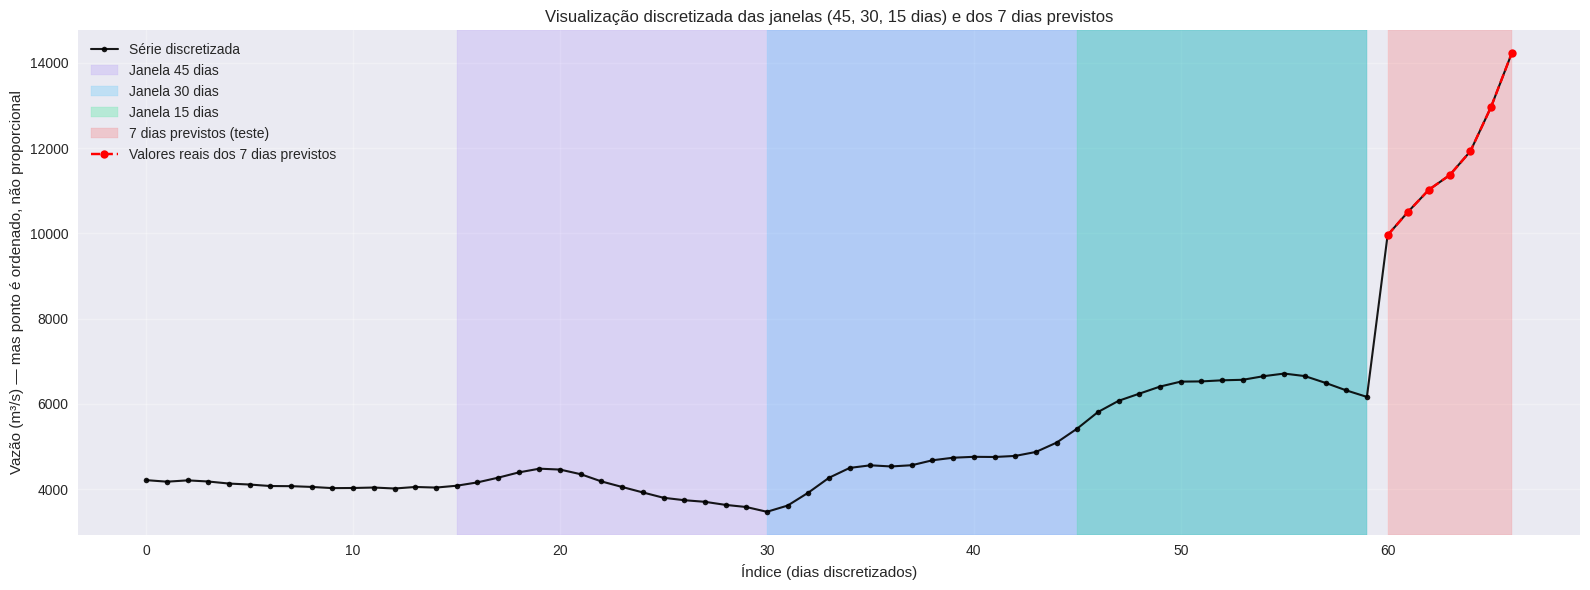

In [ ]:
#5

plt.figure(figsize=(16,6))

# --- Encontrar limites reais do treino/teste ---
split_date = np.datetime64("2011-01-01")
idx_train_end = df.index[df["Data"] < split_date].max()
idx_test_start = idx_train_end + 1

# --- Selecionar últimos 60 dias do treino + 7 dias do teste ---
N_FINAIS = 60
start_idx = max(idx_train_end - N_FINAIS + 1, 0)
end_idx   = idx_test_start + 6

segment = df.loc[start_idx:end_idx].reset_index(drop=True)

# Criar eixo X discretizado (0,1,2,3,...)
x = np.arange(len(segment))
y = segment["Vazao"]

# --- Plot discreto ---
plt.plot(x, y, '-o', color="black", markersize=4, linewidth=1.5, alpha=0.9,
         label="Série discretizada")

# --- Encontrar posições discretizadas das janelas ---
pos_train_end = (idx_train_end - start_idx)
pos_test_start = pos_train_end + 1

# Janela 45
plt.axvspan(pos_train_end - 44, pos_train_end,
            color="#7c4dff", alpha=0.15, label="Janela 45 dias")

# Janela 30
plt.axvspan(pos_train_end - 29, pos_train_end,
            color="#00b0ff", alpha=0.18, label="Janela 30 dias")

# Janela 15
plt.axvspan(pos_train_end - 14, pos_train_end,
            color="#00e676", alpha=0.22, label="Janela 15 dias")

# Futuro (7 dias do teste)
plt.axvspan(pos_test_start, pos_test_start + 6,
            color="red", alpha=0.15, label="7 dias previstos (teste)")

plt.plot(x[pos_test_start:pos_test_start+7],
         y[pos_test_start:pos_test_start+7],
         'o--', color="red", markersize=6,
         label="Valores reais dos 7 dias previstos")

# --- Estética ---
plt.title("Visualização discretizada das janelas (45, 30, 15 dias) e dos 7 dias previstos")
plt.xlabel("Índice (dias discretizados)")
plt.ylabel("Vazão (m³/s) — mas ponto é ordenado, não proporcional")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 6
print("Chaves X_train_dict:", X_train_dict.keys())
print("Chaves X_val_dict:", X_val_dict.keys())
print("Chaves X_test_dict:", X_test_dict.keys())


Chaves X_train_dict: dict_keys([15, 30, 45])
Chaves X_val_dict: dict_keys([15, 30, 45])
Chaves X_test_dict: dict_keys([15, 30, 45])


## PARTE 3 — KNN com Grid Search simples + Cross-validation (TimeSeriesSplit)

In [ ]:
# 7
best_knn_models = {}
knn_predictions = {}

# Espaço simples de hiperparâmetros
param_grid = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
}

kfolds = 5   # cross-validation k=5

for w in WINDOWS:
    print(f"\n====================================")
    print(f"      KNN — Janela {w} dias")
    print(f"====================================")

    X_train = X_train_dict[w]
    y_train = y_train_dict[w]
    X_val   = X_val_dict[w]
    y_val   = y_val_dict[w]
    X_test  = X_test_dict[w]
    y_test  = y_test_dict[w]

    tscv = TimeSeriesSplit(n_splits=kfolds)

    best_score = np.inf
    best_params = None

    # ---------- GRID SEARCH MANUAL ----------

    for k in param_grid["n_neighbors"]:
        for wtype in param_grid["weights"]:

            fold_errors = []

            for train_idx, val_idx in tscv.split(X_train):
                X_tr_cv, X_va_cv = X_train[train_idx], X_train[val_idx]
                y_tr_cv, y_va_cv = y_train[train_idx], y_train[val_idx]

                model = KNeighborsRegressor(
                    n_neighbors=k,
                    weights=wtype
                )

                model.fit(X_tr_cv, y_tr_cv)
                pred = model.predict(X_va_cv)

                fold_errors.append(mean_absolute_error(y_va_cv, pred))

            avg_error = np.mean(fold_errors)

            print(f"k={k}, weights={wtype} → MAE médio CV: {avg_error:.4f}")

            if avg_error < best_score:
                best_score = avg_error
                best_params = (k, wtype)

    print(f"\nMelhores hiperparâmetros janela {w}:")
    print(f"k = {best_params[0]}, weights = {best_params[1]}")
    print(f"MAE médio: {best_score:.4f}")

    # ---------- Treinar no treino+val inteiro ----------
    final_knn = KNeighborsRegressor(
        n_neighbors=best_params[0],
        weights=best_params[1]
    )

    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.vstack([y_train, y_val])

    final_knn.fit(X_train_full, y_train_full)

    # Guardar o modelo
    best_knn_models[w] = final_knn

    # ---------- Fazer previsões no TESTE ----------
    pred_test_scaled = final_knn.predict(X_test)

    # Reverter normalização
    scaler_y = scalers[w][1]
    pred_test = scaler_y.inverse_transform(pred_test_scaled)
    y_test_orig = scaler_y.inverse_transform(y_test)

    knn_predictions[w] = (y_test_orig, pred_test)

print("\n end 3")



      KNN — Janela 15 dias
k=3, weights=uniform → MAE médio CV: 0.0603
k=3, weights=distance → MAE médio CV: 0.0603
k=5, weights=uniform → MAE médio CV: 0.0580
k=5, weights=distance → MAE médio CV: 0.0579
k=7, weights=uniform → MAE médio CV: 0.0568
k=7, weights=distance → MAE médio CV: 0.0567
k=11, weights=uniform → MAE médio CV: 0.0555
k=11, weights=distance → MAE médio CV: 0.0553

Melhores hiperparâmetros janela 15:
k = 11, weights = distance
MAE médio: 0.0553

      KNN — Janela 30 dias
k=3, weights=uniform → MAE médio CV: 0.0719
k=3, weights=distance → MAE médio CV: 0.0720
k=5, weights=uniform → MAE médio CV: 0.0676
k=5, weights=distance → MAE médio CV: 0.0678
k=7, weights=uniform → MAE médio CV: 0.0658
k=7, weights=distance → MAE médio CV: 0.0659
k=11, weights=uniform → MAE médio CV: 0.0637
k=11, weights=distance → MAE médio CV: 0.0637

Melhores hiperparâmetros janela 30:
k = 11, weights = distance
MAE médio: 0.0637

      KNN — Janela 45 dias
k=3, weights=uniform → MAE médio CV:

## PARTE 4 — Função de criação da MLP

In [ ]:
# 8
def build_mlp(input_dim, H1=64, H2=32, lr=0.001):
    """
    Parâmetros:
        input_dim (int): tamanho da janela (15, 30 ou 45)
        H1 (int): neurônios da primeira camada oculta
        H2 (int): neurônios da segunda camada oculta
        lr (float): learning rate do otimizador
    """

    model = Sequential([
        Dense(H1, activation="relu", input_shape=(input_dim,)),
        Dense(H2, activation="relu"),
        Dense(7, activation="linear")   # saída multistep de 7 dias
    ])

    optimizer = Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    return model

print("func definida")


func definida


## PARTE 5 — Random Search leve para MLP + Treino final

In [ ]:
# 9

import random
from tensorflow.keras.callbacks import EarlyStopping

best_mlp_models = {}
mlp_predictions = {}

N_COMBINATIONS = 5   # leve, rápido e dentro do escopo

search_space = {
    "H1": [32, 64, 96, 128],
    "H2": [16, 32, 48, 64],
    "lr": [1e-2, 5e-3, 1e-3]
}

for w in WINDOWS:
    print("\n====================================")
    print(f"   MLP — Random Search (Janela {w})")
    print("====================================")

    X_train = X_train_dict[w]
    y_train = y_train_dict[w]

    X_val   = X_val_dict[w]
    y_val   = y_val_dict[w]

    input_dim = X_train.shape[1]

    best_score = np.inf
    best_params = None
    best_model_temp = None

    # -------- LOOP DO RANDOM SEARCH --------
    for i in range(N_COMBINATIONS):
        H1 = random.choice(search_space["H1"])
        H2 = random.choice(search_space["H2"])
        lr = random.choice(search_space["lr"])

        print(f"\nCombinação {i+1}/{N_COMBINATIONS} → H1={H1}, H2={H2}, lr={lr}")

        model = build_mlp(input_dim, H1=H1, H2=H2, lr=lr) #criação da mlp para desempenho

        early = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=200,
            batch_size=32,
            verbose=0,
            callbacks=[early]
        )

        val_mae = min(history.history["val_mae"])
        print(f"→ Val_MAE = {val_mae:.4f}")

        if val_mae < best_score:
            best_score = val_mae
            best_params = (H1, H2, lr)
            best_model_temp = model

    print(f"\nMelhores hiperparâmetros para janela {w}:")
    print(f"H1={best_params[0]}, H2={best_params[1]}, lr={best_params[2]}")
    print(f"Melhor Val_MAE={best_score:.4f}")

    # -------- Treino final no conjunto TREINO + VAL --------

    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.vstack([y_train, y_val])

    H1, H2, lr = best_params
    final_model = build_mlp(input_dim, H1, H2, lr)  ##### valores enconraor pelo random são entregues

    early = EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True
    )

    final_model.fit(
        X_train_full, y_train_full,
        epochs=300,
        batch_size=32,
        verbose=0,
        callbacks=[early]
    )

    best_mlp_models[w] = final_model

    # -------- Previsões no TESTE --------

    X_test = X_test_dict[w]
    y_test_scaled = y_test_dict[w]

    pred_scaled = final_model.predict(X_test)

    scaler_y = scalers[w][1]
    pred_test = scaler_y.inverse_transform(pred_scaled)
    y_test_orig = scaler_y.inverse_transform(y_test_scaled)

    mlp_predictions[w] = (y_test_orig, pred_test)

print("\n end 5")



   MLP — Random Search (Janela 15)

Combinação 1/5 → H1=32, H2=32, lr=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


→ Val_MAE = 0.0391

Combinação 2/5 → H1=64, H2=48, lr=0.01
→ Val_MAE = 0.0408

Combinação 3/5 → H1=96, H2=16, lr=0.005
→ Val_MAE = 0.0405

Combinação 4/5 → H1=96, H2=16, lr=0.001
→ Val_MAE = 0.0397

Combinação 5/5 → H1=64, H2=32, lr=0.001
→ Val_MAE = 0.0396

Melhores hiperparâmetros para janela 15:
H1=32, H2=32, lr=0.001
Melhor Val_MAE=0.0391
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

   MLP — Random Search (Janela 30)

Combinação 1/5 → H1=128, H2=16, lr=0.005


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


→ Val_MAE = 0.0416

Combinação 2/5 → H1=32, H2=16, lr=0.005
→ Val_MAE = 0.0407

Combinação 3/5 → H1=128, H2=48, lr=0.005
→ Val_MAE = 0.0415

Combinação 4/5 → H1=96, H2=16, lr=0.001
→ Val_MAE = 0.0402

Combinação 5/5 → H1=96, H2=32, lr=0.001
→ Val_MAE = 0.0404

Melhores hiperparâmetros para janela 30:
H1=96, H2=16, lr=0.001
Melhor Val_MAE=0.0402
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

   MLP — Random Search (Janela 45)

Combinação 1/5 → H1=32, H2=64, lr=0.01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


→ Val_MAE = 0.0408

Combinação 2/5 → H1=96, H2=48, lr=0.005
→ Val_MAE = 0.0421

Combinação 3/5 → H1=32, H2=48, lr=0.005
→ Val_MAE = 0.0422

Combinação 4/5 → H1=128, H2=32, lr=0.01
→ Val_MAE = 0.0423

Combinação 5/5 → H1=32, H2=32, lr=0.01
→ Val_MAE = 0.0424

Melhores hiperparâmetros para janela 45:
H1=32, H2=64, lr=0.01
Melhor Val_MAE=0.0408
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 end 5


## PARTE 6 — Ensemble por Média Simples

In [ ]:
# 10

ensemble_predictions = {}

for w in WINDOWS:
    print("\n====================================")
    print(f"   ENSEMBLE — Janela {w} dias")
    print("====================================")

    # Recupera previsões do KNN e MLP
    y_true_knn, y_pred_knn = knn_predictions[w]
    y_true_mlp, y_pred_mlp = mlp_predictions[w]

    # Garantir que y_true dos dois é idêntico
    y_true = y_true_knn

    # Média simples
    y_pred_ensemble = (y_pred_knn + y_pred_mlp) / 2.0

    # Salvar
    ensemble_predictions[w] = (y_true, y_pred_ensemble)

    print(f"Ensemble criado para janela {w} (shape: {y_pred_ensemble.shape})")

print("\nPARTE 6 concluída —— Ensemble gerado para todas as janelas.")



   ENSEMBLE — Janela 15 dias
Ensemble criado para janela 15 (shape: (918, 7))

   ENSEMBLE — Janela 30 dias
Ensemble criado para janela 30 (shape: (918, 7))

   ENSEMBLE — Janela 45 dias
Ensemble criado para janela 45 (shape: (918, 7))

PARTE 6 concluída —— Ensemble gerado para todas as janelas.


In [ ]:
# 11
def inspect_predictions(model_dict, name):
    print("\n=======================================")
    print(f"   INSPEÇÃO DE {name.upper()}")
    print("=======================================")

    for w in WINDOWS:
        print(f"\n--- Janela {w} dias ---")

        y_true, y_pred = model_dict[w]

        print(f"Shape y_true: {y_true.shape}")
        print(f"Shape y_pred: {y_pred.shape}")

        print("\nPrimeiros valores (y_true vs y_pred):")
        df_tmp = pd.DataFrame({
            "y_true_1": y_true[:,0],
            "y_pred_1": y_pred[:,0]
        })

        display(df_tmp.head())


#KNN
inspect_predictions(knn_predictions, "knn")

#MLP
inspect_predictions(mlp_predictions, "mlp")

#Ensemble
inspect_predictions(ensemble_predictions, "ensemble")

print("\n end")



   INSPEÇÃO DE KNN

--- Janela 15 dias ---
Shape y_true: (918, 7)
Shape y_pred: (918, 7)

Primeiros valores (y_true vs y_pred):


,y_true_1,y_pred_1
0,6651.0,7065.582106
1,6713.0,6848.201798
2,6654.0,6318.873484
3,6494.0,6360.268767
4,6319.0,6304.320233



--- Janela 30 dias ---
Shape y_true: (918, 7)
Shape y_pred: (918, 7)

Primeiros valores (y_true vs y_pred):


,y_true_1,y_pred_1
0,6651.0,6960.777308
1,6713.0,6762.704093
2,6654.0,6268.939268
3,6494.0,6193.259850
4,6319.0,6989.132293



--- Janela 45 dias ---
Shape y_true: (918, 7)
Shape y_pred: (918, 7)

Primeiros valores (y_true vs y_pred):


...


--- Janela 30 dias ---
Shape y_true: (918, 7)
Shape y_pred: (918, 7)

Primeiros valores (y_true vs y_pred):


,y_true_1,y_pred_1
0,6651.0,6835.225568
1,6713.0,6822.427242
2,6654.0,6612.393706
3,6494.0,6514.059856
4,6319.0,6813.077377



--- Janela 45 dias ---
Shape y_true: (918, 7)
Shape y_pred: (918, 7)

Primeiros valores (y_true vs y_pred):


,y_true_1,y_pred_1
0,6651.0,6404.722035
1,6713.0,6388.613548
2,6654.0,6493.391313
3,6494.0,6460.416792
4,6319.0,6363.478738



 end


## PARTE 7 — Avaliação completa (MAE, MAPE, MSE)

In [ ]:
# 12
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100


results = []

for w in WINDOWS:
    print("\n=======================================")
    print(f"   MÉTRICAS — Janela {w} dias")
    print("=======================================\n")

    # Recuperar previsões
    y_true_knn, y_pred_knn = knn_predictions[w]
    y_true_mlp, y_pred_mlp = mlp_predictions[w]
    y_true_ens, y_pred_ens = ensemble_predictions[w]

    # Como os valores verdadeiros são iguais:
    y_true = y_true_knn

    # ----- KNN -----
    mae_knn = mean_absolute_error(y_true, y_pred_knn)
    mape_knn = mape(y_true, y_pred_knn)
    mse_knn = mean_squared_error(y_true, y_pred_knn)

    # ----- MLP -----
    mae_mlp = mean_absolute_error(y_true, y_pred_mlp)
    mape_mlp = mape(y_true, y_pred_mlp)
    mse_mlp = mean_squared_error(y_true, y_pred_mlp)

    # ----- ENSEMBLE -----
    mae_ens = mean_absolute_error(y_true, y_pred_ens)
    mape_ens = mape(y_true, y_pred_ens)
    mse_ens = mean_squared_error(y_true, y_pred_ens)


    print(f"KNN:      MAE={mae_knn:.4f} | MAPE={mape_knn:.3f}% | MSE={mse_knn:.2f}")
    print(f"MLP:      MAE={mae_mlp:.4f} | MAPE={mape_mlp:.3f}% | MSE={mse_mlp:.2f}")
    print(f"Ensemble: MAE={mae_ens:.4f} | MAPE={mape_ens:.3f}% | MSE={mse_ens:.2f}")

    # Salvar no DataFrame consolidado
    results.append([w, "KNN", mae_knn, mape_knn, mse_knn])
    results.append([w, "MLP", mae_mlp, mape_mlp, mse_mlp])
    results.append([w, "Ensemble", mae_ens, mape_ens, mse_ens])

# ----------- DataFrame final para relatório -----------

df_results = pd.DataFrame(
    results,
    columns=["Janela", "Modelo", "MAE", "MAPE (%)", "MSE"]
)

print("\n\n=========== TABELA FINAL DE RESULTADOS ===========\n")
display(df_results)

print("\n end 7")



   MÉTRICAS — Janela 15 dias

KNN:      MAE=1196.5879 | MAPE=17.853% | MSE=3861917.83
MLP:      MAE=934.0078 | MAPE=14.282% | MSE=2446243.05
Ensemble: MAE=1017.9886 | MAPE=15.361% | MSE=2836489.25

   MÉTRICAS — Janela 30 dias

KNN:      MAE=1361.3013 | MAPE=19.066% | MSE=4729881.83
MLP:      MAE=1001.4171 | MAPE=15.443% | MSE=2863213.36
Ensemble: MAE=1093.8623 | MAPE=16.037% | MSE=3191377.69

   MÉTRICAS — Janela 45 dias

KNN:      MAE=1390.5348 | MAPE=20.812% | MSE=4622355.31
MLP:      MAE=966.5823 | MAPE=13.915% | MSE=2810437.50
Ensemble: MAE=1128.5012 | MAPE=16.566% | MSE=3353885.31


=========== TABELA FINAL DE RESULTADOS ===========



,Janela,Modelo,MAE,MAPE (%),MSE
0,15,KNN,1196.587938,17.852618,3.861918e+06
1,15,MLP,934.007808,14.282073,2.446243e+06
2,15,Ensemble,1017.988590,15.360905,2.836489e+06
3,30,KNN,1361.301281,19.066070,4.729882e+06
4,30,MLP,1001.417084,15.442721,2.863213e+06
5,30,Ensemble,1093.862319,16.037437,3.191378e+06
6,45,KNN,1390.534759,20.811715,4.622355e+06
7,45,MLP,966.582284,13.914600,2.810438e+06
8,45,Ensemble,1128.501172,16.565990,3.353885e+06



 end 7


## PARTE 8 — Teste de Hipóteses (Wilcoxon)

In [ ]:

#13
def wilcoxon_compare(errors_A, errors_B, labelA, labelB, window):
    """
    Executa o Wilcoxon Signed-Rank Test entre dois modelos.
    """
    stat, p = wilcoxon(errors_A, errors_B)

    print("\n-----------------------------------------")
    print(f" Wilcoxon — Janela {window} — {labelA} vs {labelB}")
    print("-----------------------------------------")
    print(f"Estatística W = {stat:.4f}")
    print(f"p-valor = {p:.6f}")

    alpha = 0.05

    if p < alpha:
        print(f"❗ Diferença SIGNIFICATIVA entre {labelA} e {labelB} (p < 0.05).")
    else:
        print(f"✔ Sem diferença significativa entre {labelA} e {labelB} (p >= 0.05).")


print("==============================================")
print("       TESTES DE HIPÓTESES — WILCOXON")
print("==============================================\n")

for w in WINDOWS:
    # Recuperar valores reais e previstos
    y_true_knn, y_pred_knn = knn_predictions[w]
    y_true_mlp, y_pred_mlp = mlp_predictions[w]
    y_true_ens, y_pred_ens = ensemble_predictions[w]

    # Erros absolutos por amostra (soma dos 7 dias)
    err_knn = np.mean(np.abs(y_true_knn - y_pred_knn), axis=1)
    err_mlp = np.mean(np.abs(y_true_mlp - y_pred_mlp), axis=1)
    err_ens = np.mean(np.abs(y_true_ens - y_pred_ens), axis=1)

    # -------- TESTES --------
    wilcoxon_compare(err_knn, err_mlp, "KNN", "MLP", w)
    wilcoxon_compare(err_mlp, err_ens, "MLP", "Ensemble", w)
    wilcoxon_compare(err_knn, err_ens, "KNN", "Ensemble", w)

print("\n end 13")


       TESTES DE HIPÓTESES — WILCOXON


-----------------------------------------
 Wilcoxon — Janela 15 — KNN vs MLP
-----------------------------------------
Estatística W = 141593.0000
p-valor = 0.000000
❗ Diferença SIGNIFICATIVA entre KNN e MLP (p < 0.05).

-----------------------------------------
 Wilcoxon — Janela 15 — MLP vs Ensemble
-----------------------------------------
Estatística W = 177984.0000
p-valor = 0.000042
❗ Diferença SIGNIFICATIVA entre MLP e Ensemble (p < 0.05).

-----------------------------------------
 Wilcoxon — Janela 15 — KNN vs Ensemble
-----------------------------------------
Estatística W = 110994.0000
p-valor = 0.000000
❗ Diferença SIGNIFICATIVA entre KNN e Ensemble (p < 0.05).

-----------------------------------------
 Wilcoxon — Janela 30 — KNN vs MLP
-----------------------------------------
Estatística W = 129580.0000
p-valor = 0.000000
❗ Diferença SIGNIFICATIVA entre KNN e MLP (p < 0.05).

-----------------------------------------
 Wilcoxon — Ja

## PARTE 9 - Avaliação + Gráficos + Comparação + Resumo

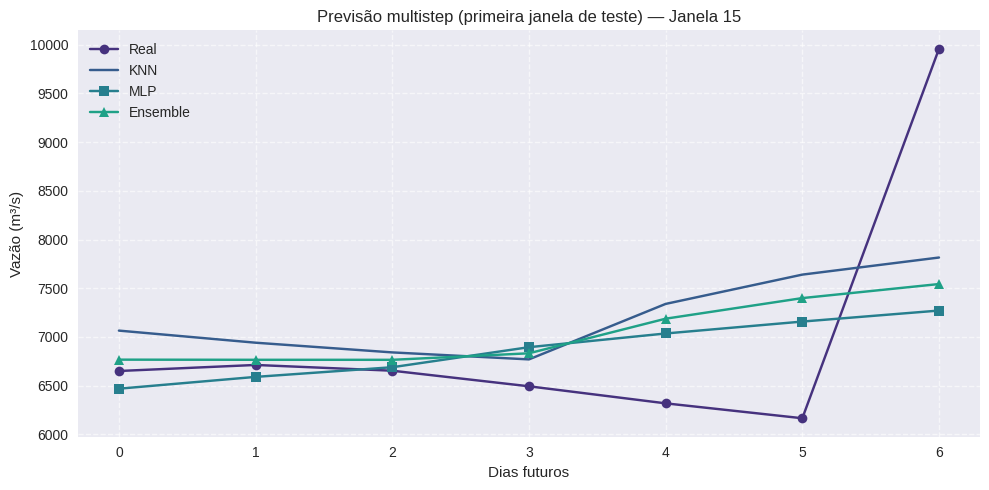

/tmp/ipython-input-3966999919.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([err_knn, err_mlp, err_ens], labels=["KNN", "MLP", "Ensemble"])


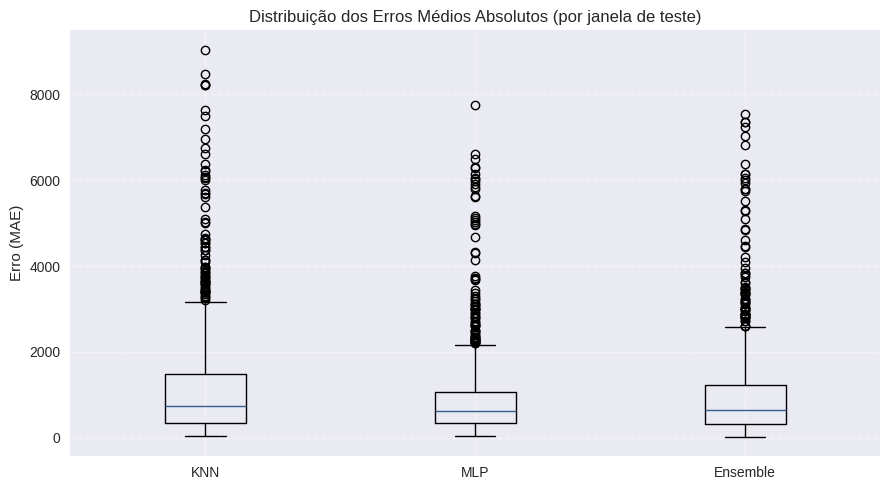

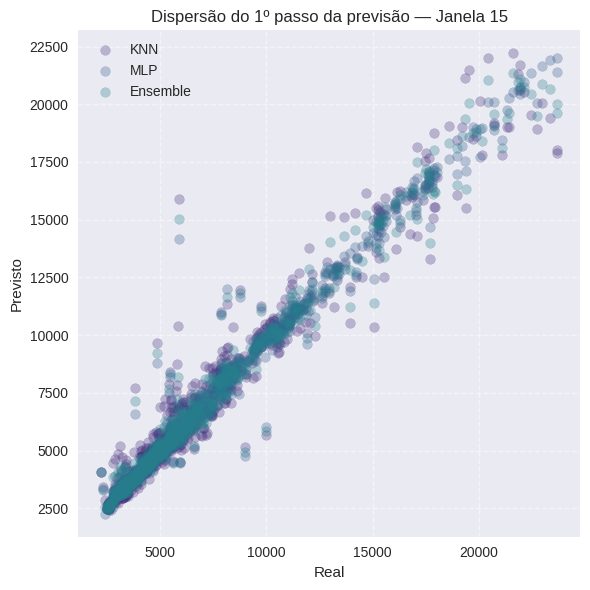



                 RESULTADOS FINAIS DO PROJETO

--- MÉTRICAS GERAIS (Janela 15) ---
KNN:      MAE=1196.588 | MAPE=17.85% | MSE=3861917.8
MLP:      MAE=934.008 | MAPE=14.28% | MSE=2446243.0
Ensemble: MAE=1017.989 | MAPE=15.36% | MSE=2836489.2

--- MODELO VENCEDOR ---
Melhor modelo (menor MAE): **MLP**

--- CONFIGURAÇÃO DO PROBLEMA ---
Tipo de problema: Regressão multistep (7 dias)
Janelas testadas: 15, 30, 45 dias
Melhor janela observada: 15 dias

--- INFO SOBRE A MLP ESCOLHIDA ---
Camadas ocultas: H1=32, H2=64
Learning rate: 0.01
Ativação oculta: ReLU
Ativação saída: Linear
Função de perda: MSE
Otimizador: Adam

--- DIVISÃO TEMPORAL ---
Treino/validação: até 2010
Teste: 2011–2016
Amostras de teste: 918 janelas

             ANÁLISE COMPLETA FINALIZADA


In [ ]:
# 14
# 1) Escolher uma janela para análise aprofundada (15 dias)
W = 15  # janela principal para gráficos e explicações

y_true, y_pred_knn = knn_predictions[W]
_,      y_pred_mlp = mlp_predictions[W]
_,      y_pred_ens = ensemble_predictions[W]

# Usar apenas a primeira previsão multistep para gráficos detalhados
y_true_1 = y_true[0]
knn_1    = y_pred_knn[0]
mlp_1    = y_pred_mlp[0]
ens_1    = y_pred_ens[0]

# Erros médios por modelo
mae_knn  = mean_absolute_error(y_true, y_pred_knn)
mae_mlp  = mean_absolute_error(y_true, y_pred_mlp)
mae_ens  = mean_absolute_error(y_true, y_pred_ens)

mape_knn = np.mean(np.abs((y_true - y_pred_knn) / (y_true + 1e-9))) * 100
mape_mlp = np.mean(np.abs((y_true - y_pred_mlp) / (y_true + 1e-9))) * 100
mape_ens = np.mean(np.abs((y_true - y_pred_ens) / (y_true + 1e-9))) * 100

mse_knn  = mean_squared_error(y_true, y_pred_knn)
mse_mlp  = mean_squared_error(y_true, y_pred_mlp)
mse_ens  = mean_squared_error(y_true, y_pred_ens)

# Escolher o vencedor
model_scores = {
    "KNN": mae_knn,
    "MLP": mae_mlp,
    "Ensemble": mae_ens
}
best_model = min(model_scores, key=model_scores.get)

# ======================================================
# 2) Gráfico — Previsão multistep da primeira janela
# ======================================================
plt.figure(figsize=(10,5))
plt.plot(y_true_1, label="Real", marker="o")
plt.plot(knn_1,  label="KNN", marker="x")
plt.plot(mlp_1,  label="MLP", marker="s")
plt.plot(ens_1,  label="Ensemble", marker="^")
plt.title(f"Previsão multistep (primeira janela de teste) — Janela {W}")
plt.xlabel("Dias futuros")
plt.ylabel("Vazão (m³/s)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# ======================================================
# 3) Boxplot — Distribuição dos erros
# ======================================================
err_knn = np.mean(np.abs(y_true - y_pred_knn), axis=1)
err_mlp = np.mean(np.abs(y_true - y_pred_mlp), axis=1)
err_ens = np.mean(np.abs(y_true - y_pred_ens), axis=1)

plt.figure(figsize=(9,5))
plt.boxplot([err_knn, err_mlp, err_ens], labels=["KNN", "MLP", "Ensemble"])
plt.title("Distribuição dos Erros Médios Absolutos (por janela de teste)")
plt.ylabel("Erro (MAE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 4) Dispersão y_true vs y_pred (primeiro passo da previsão)
# ======================================================
plt.figure(figsize=(6,6))
plt.scatter(y_true[:,0], y_pred_knn[:,0], alpha=0.3, label="KNN")
plt.scatter(y_true[:,0], y_pred_mlp[:,0], alpha=0.3, label="MLP")
plt.scatter(y_true[:,0], y_pred_ens[:,0], alpha=0.3, label="Ensemble")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.title("Dispersão do 1º passo da previsão — Janela 15")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ======================================================
# 5) Impressão detalhada dos resultados numéricos
# ======================================================

print("\n\n" + "="*70)
print("                 RESULTADOS FINAIS DO PROJETO")
print("="*70)

print("\n--- MÉTRICAS GERAIS (Janela 15) ---")
print(f"KNN:      MAE={mae_knn:.3f} | MAPE={mape_knn:.2f}% | MSE={mse_knn:.1f}")
print(f"MLP:      MAE={mae_mlp:.3f} | MAPE={mape_mlp:.2f}% | MSE={mse_mlp:.1f}")
print(f"Ensemble: MAE={mae_ens:.3f} | MAPE={mape_ens:.2f}% | MSE={mse_ens:.1f}")

print("\n--- MODELO VENCEDOR ---")
print(f"Melhor modelo (menor MAE): **{best_model}**")

print("\n--- CONFIGURAÇÃO DO PROBLEMA ---")
print(f"Tipo de problema: Regressão multistep (7 dias)")
print(f"Janelas testadas: 15, 30, 45 dias")
print(f"Melhor janela observada: 15 dias")

print("\n--- INFO SOBRE A MLP ESCOLHIDA ---")
H1, H2, lr = best_params  # do random search
print(f"Camadas ocultas: H1={H1}, H2={H2}")
print(f"Learning rate: {lr}")
print("Ativação oculta: ReLU")
print("Ativação saída: Linear")
print("Função de perda: MSE")
print("Otimizador: Adam")

print("\n--- DIVISÃO TEMPORAL ---")
print("Treino/validação: até 2010")
print("Teste: 2011–2016")
print(f"Amostras de teste: {len(y_true)} janelas")

print("\n" + "="*70)
print("             ANÁLISE COMPLETA FINALIZADA")
print("="*70)


### Leitura:
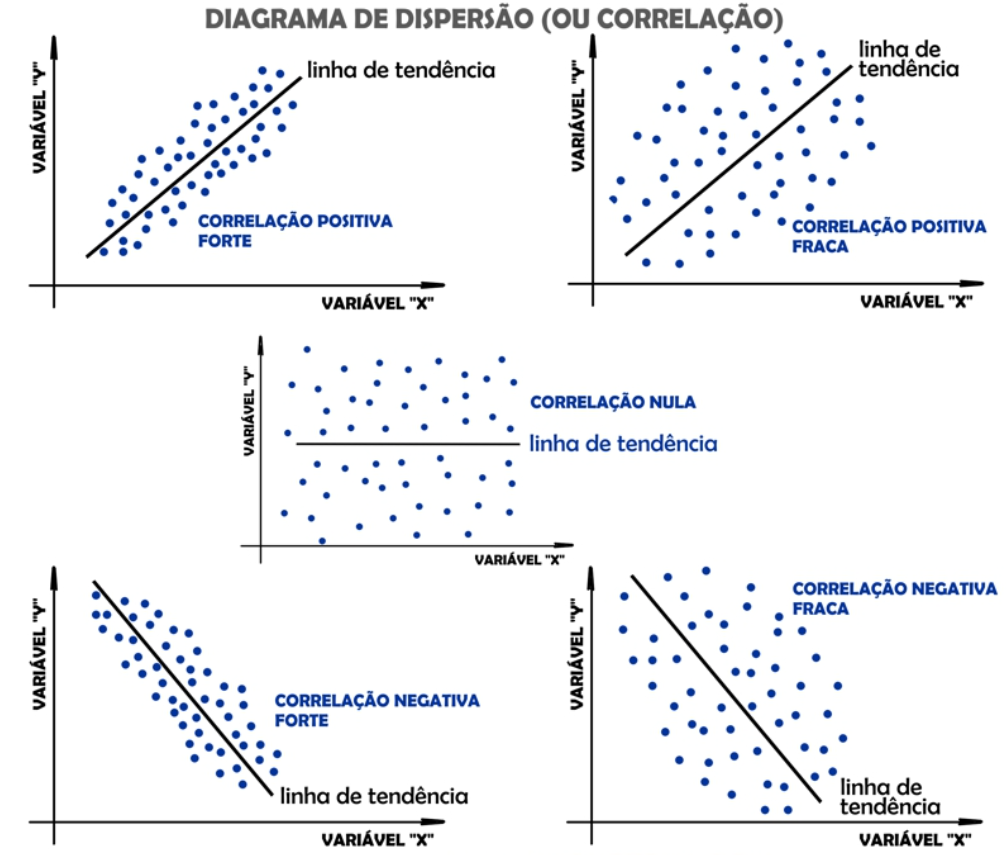

---

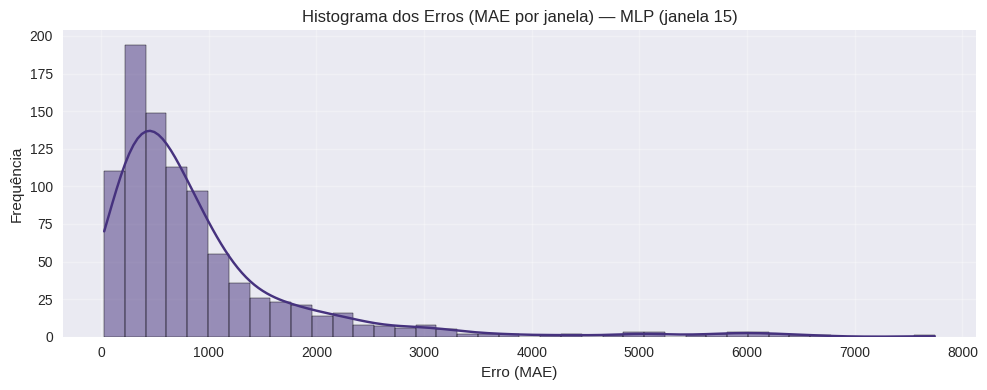

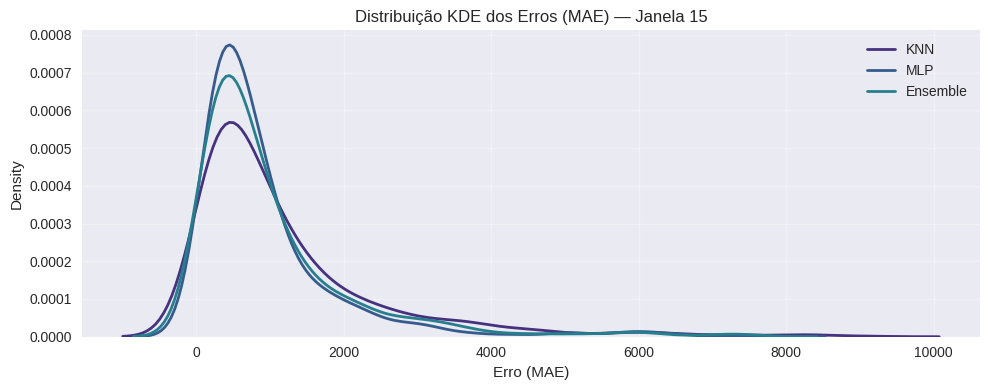

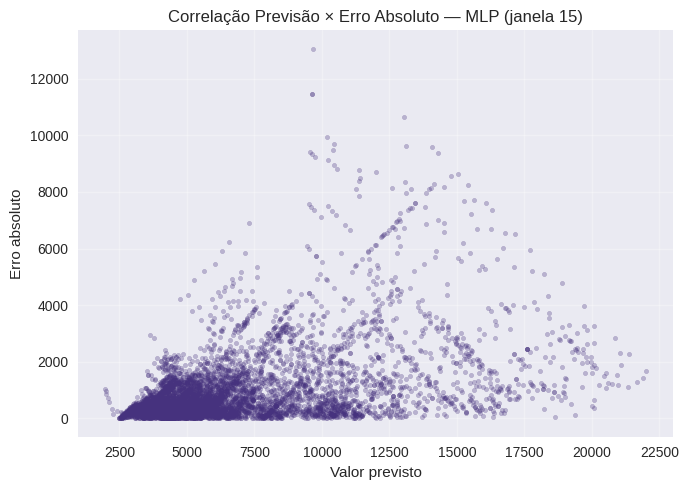

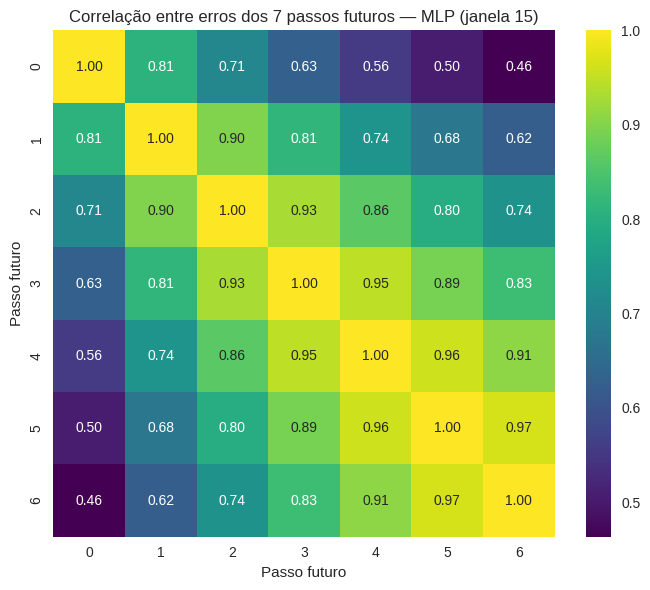

In [ ]:
# ============================================================
#   GRÁFICOS EXTRA PARA APRESENTAÇÃO — CORRIGIDO 100%
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 0) Recuperar previsões e erros da janela 15
# (os erros por janela já foram calculados na parte 9)
# ------------------------------------------------------------

y_true_15, y_pred_mlp_15 = mlp_predictions[15]

# Erros por passo
errors_15 = y_true_15 - y_pred_mlp_15
abs_errors_15 = np.abs(errors_15)

# MAE por janela
mae_per_window = np.mean(abs_errors_15, axis=1)

# ERROS DOS 3 MODELOS (já calculados na parte 9)
err_knn_15 = err_knn      # KNN — erros médios por janela
err_mlp_15 = err_mlp      # MLP — erros médios por janela
err_ens_15 = err_ens      # Ensemble — erros médios por janela


# ------------------------------------------------------------
# 1) HISTOGRAMA dos erros (MLP — janela 15)
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
sns.histplot(mae_per_window, bins=40, kde=True)
plt.title("Histograma dos Erros (MAE por janela) — MLP (janela 15)")
plt.xlabel("Erro (MAE)")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2) KDE — Distribuição dos erros dos modelos
# ------------------------------------------------------------
plt.figure(figsize=(10,4))
sns.kdeplot(err_knn_15, label="KNN", linewidth=2)
sns.kdeplot(err_mlp_15, label="MLP", linewidth=2)
sns.kdeplot(err_ens_15, label="Ensemble", linewidth=2)
plt.title("Distribuição KDE dos Erros (MAE) — Janela 15")
plt.xlabel("Erro (MAE)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3) Dispersão: Previsão × Erro Absoluto (MLP – janela 15)
# ------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(y_pred_mlp_15.flatten(),
            abs_errors_15.flatten(),
            alpha=0.3, s=10)
plt.title("Correlação Previsão × Erro Absoluto — MLP (janela 15)")
plt.xlabel("Valor previsto")
plt.ylabel("Erro absoluto")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4) Heatmap — Correlação entre os 7 passos previstos
# ------------------------------------------------------------
corr = np.corrcoef(errors_15.T)

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlação entre erros dos 7 passos futuros — MLP (janela 15)")
plt.xlabel("Passo futuro")
plt.ylabel("Passo futuro")
plt.tight_layout()
plt.show()


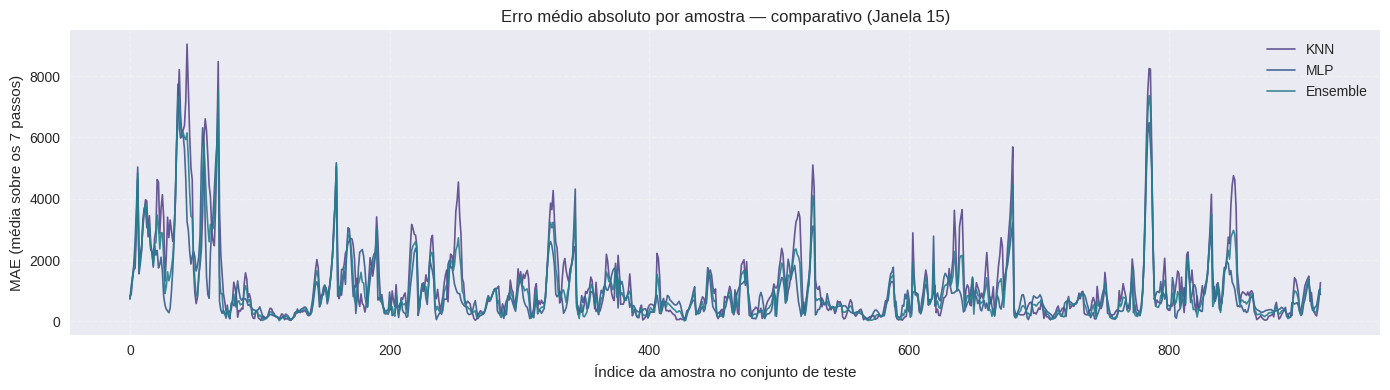

Resumo MAE médio por modelo (janela 15):
  MAE médio KNN      = 1196.5879 (std = 1343.4226)
  MAE médio MLP      = 934.0078 (std = 1027.4804)
  MAE médio Ensemble = 1017.9886 (std = 1133.6933)



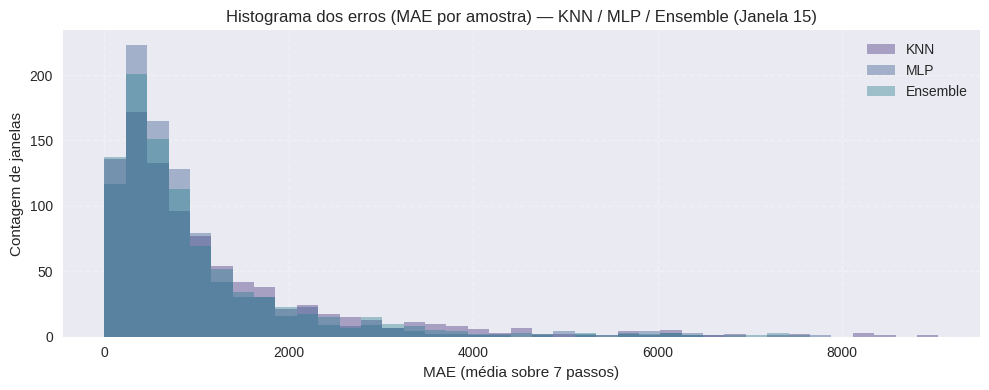

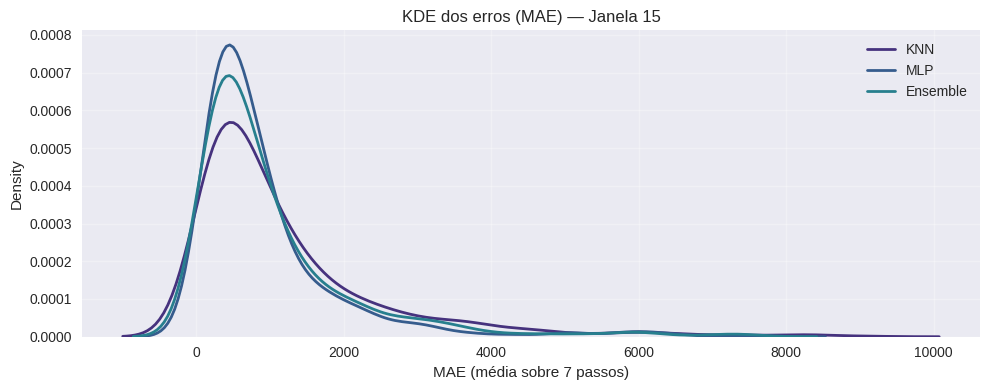

In [ ]:
# 16
W = 15  # janela de interesse

# ---- checagens rápidas ----
for dname in ("knn_predictions", "mlp_predictions", "ensemble_predictions"):
    if dname not in globals():
        raise NameError(f"Variável '{dname}' não encontrada. Execute as Partes 3-6 antes desta célula.")

# ---- extrair previsões (valores já em escala original — inverse_transform já aplicado) ----
y_knn, y_pred_knn = knn_predictions[W]
y_mlp,  y_pred_mlp  = mlp_predictions[W]
y_ens,  y_pred_ens  = ensemble_predictions[W]

# sanity check shapes
if not (y_knn.shape == y_mlp.shape == y_ens.shape):
    raise ValueError("Shapes de y_true diferentes entre modelos.")
if not (y_pred_knn.shape == y_pred_mlp.shape == y_pred_ens.shape):
    raise ValueError("Shapes de y_pred diferentes entre modelos.")

# ---- calcular erro médio por amostra (média sobre os HORIZON passos) ----
err_knn = np.mean(np.abs(y_knn - y_pred_knn), axis=1)      # shape (N,)
err_mlp = np.mean(np.abs(y_mlp - y_pred_mlp), axis=1)
err_ens = np.mean(np.abs(y_ens - y_pred_ens), axis=1)

# ---- 1) Erro ao longo do tempo (MAE por amostra) ----
plt.figure(figsize=(14,4))
plt.plot(err_knn, label="KNN", linewidth=1.2, alpha=0.8)
plt.plot(err_mlp, label="MLP", linewidth=1.2, alpha=0.9)
plt.plot(err_ens, label="Ensemble", linewidth=1.2, alpha=0.9)
plt.title(f"Erro médio absoluto por amostra — comparativo (Janela {W})")
plt.xlabel("Índice da amostra no conjunto de teste")
plt.ylabel("MAE (média sobre os 7 passos)")
plt.legend()
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# ---- imprimir estatísticas resumidas ----
print("Resumo MAE médio por modelo (janela {}):".format(W))
print(f"  MAE médio KNN      = {np.mean(err_knn):.4f} (std = {np.std(err_knn):.4f})")
print(f"  MAE médio MLP      = {np.mean(err_mlp):.4f} (std = {np.std(err_mlp):.4f})")
print(f"  MAE médio Ensemble = {np.mean(err_ens):.4f} (std = {np.std(err_ens):.4f})")
print()

# ---- 2) Histograma comparativo dos erros (mesma métrica MAE por amostra) ----
plt.figure(figsize=(10,4))
bins = np.linspace(0, max(err_knn.max(), err_mlp.max(), err_ens.max()), 40)
plt.hist(err_knn, bins=bins, alpha=0.4, label="KNN", density=False)
plt.hist(err_mlp, bins=bins, alpha=0.4, label="MLP", density=False)
plt.hist(err_ens, bins=bins, alpha=0.4, label="Ensemble", density=False)
plt.title(f"Histograma dos erros (MAE por amostra) — KNN / MLP / Ensemble (Janela {W})")
plt.xlabel("MAE (média sobre 7 passos)")
plt.ylabel("Contagem de janelas")
plt.legend()
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# ---- (opcional) KDE sobreposto para visualização suave ----
plt.figure(figsize=(10,4))
sns.kdeplot(err_knn, label="KNN", linewidth=2)
sns.kdeplot(err_mlp, label="MLP", linewidth=2)
sns.kdeplot(err_ens, label="Ensemble", linewidth=2)
plt.title(f"KDE dos erros (MAE) — Janela {W}")
plt.xlabel("MAE (média sobre 7 passos)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
